# Polynomial Regression - Phase 1: Steam Turbine Optimization (var1)
Selecting the degree, the features and the regularization using K-Fold cross validation.

In [1]:
import itertools
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score

warnings.filterwarnings("ignore")   # hide lasso convergence warnings

k = 10
max_degree = 10

## Loading the data

In [2]:
train = pd.read_csv("BT2024028_train_var1.csv")
test = pd.read_csv("BT2024028_test_var1.csv")

features = ["x1", "x2", "x3", "x4", "x5", "x6"]

print(train.shape, test.shape)
train.head()

(1000, 7) (1000, 6)


,x1,x2,x3,x4,x5,x6,y
0,0.000870,-0.948117,-1.000000,-0.832550,0.023252,0.491280,-3.653045
1,-0.591041,-1.000000,-1.000000,-1.000000,-0.532134,-1.000000,4.032743
2,-0.412773,0.242323,-0.948002,-0.133201,1.000000,0.228447,1.007571
3,0.661279,0.972421,0.677843,1.000000,1.000000,-0.159258,-3.597105
4,-1.000000,-0.231814,0.833907,-0.547066,1.000000,-0.354091,1.898951


## K-Fold cross validation
For a given set of features and degree, the model is fit on k-1 folds and validated on the remaining fold. The average train and validation MSE and R2 are returned.

`reg` can be `none` (plain least squares), `ridge` or `lasso`.

In [3]:
def build_model(degree, reg="none", alpha=1.0):
    # scale inputs to [-1, 1] so high powers stay stable
    scale = MinMaxScaler(feature_range=(-1, 1))
    poly = PolynomialFeatures(degree, include_bias=False)

    if reg == "none":
        return make_pipeline(scale, poly, LinearRegression())

    # standardise the polynomial terms before applying the penalty
    if reg == "ridge":
        return make_pipeline(scale, poly, StandardScaler(), Ridge(alpha=alpha))
    if reg == "lasso":
        return make_pipeline(scale, poly, StandardScaler(), Lasso(alpha=alpha, max_iter=5000, tol=1e-3))


def kfold_scores(feature_list, degree, reg="none", alpha=1.0):
    X = train[feature_list].values
    y = train["y"].values
    kf = KFold(n_splits=k, shuffle=True, random_state=42)

    train_mse, val_mse, train_r2, val_r2 = [], [], [], []

    for train_idx, val_idx in kf.split(X):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]

        model = build_model(degree, reg, alpha)
        model.fit(X_tr, y_tr)

        pred_tr = model.predict(X_tr)
        pred_val = model.predict(X_val)

        train_mse.append(mean_squared_error(y_tr, pred_tr))
        val_mse.append(mean_squared_error(y_val, pred_val))
        train_r2.append(r2_score(y_tr, pred_tr))
        val_r2.append(r2_score(y_val, pred_val))

    return np.mean(train_mse), np.mean(val_mse), np.mean(train_r2), np.mean(val_r2)

## Determining the degree of the model

In [4]:
rows = []
for degree in range(1, max_degree + 1):
    tr_mse, v_mse, tr_r2, v_r2 = kfold_scores(features, degree)
    rows.append([degree, tr_mse, v_mse, tr_r2, v_r2])

degree_results = pd.DataFrame(rows, columns=["degree", "train_mse", "val_mse", "train_r2", "val_r2"])
print(degree_results)

   degree     train_mse     val_mse  train_r2     val_r2
0       1  9.748758e+00    9.885140  0.131701   0.110804
1       2  3.250582e+00    3.513429  0.710415   0.677831
2       3  8.011727e-01    1.017784  0.928630   0.906880
3       4  3.628750e-01    0.705487  0.967673   0.935350
4       5  1.282778e-01    0.964144  0.988573   0.910471
5       6  3.863395e-26  937.009958  1.000000 -85.563569
6       7  7.693933e-28    6.138524  1.000000   0.445202
7       8  6.725826e-28    3.749032  1.000000   0.658039
8       9  8.093198e-28    3.115240  1.000000   0.719489
9      10  1.795005e-27    2.938155  1.000000   0.734869


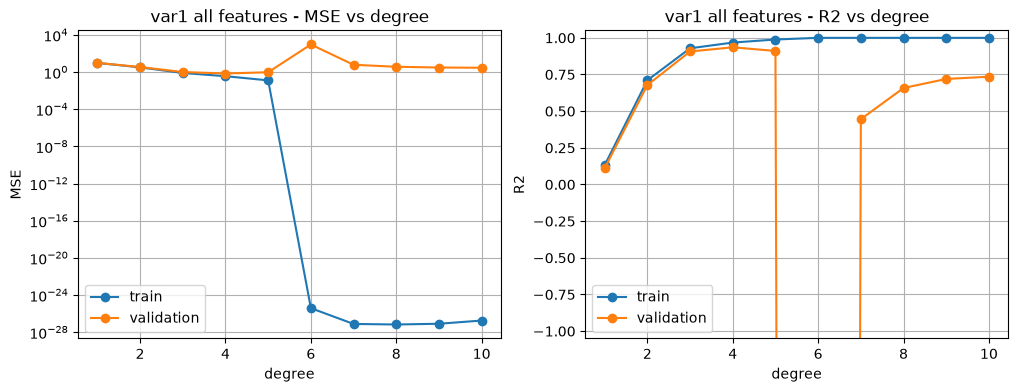

In [5]:
def plot_degree_sweep(results, title, file_name):
    fig, (mse_plot, r2_plot) = plt.subplots(1, 2, figsize=(12, 4))

    mse_plot.plot(results["degree"], results["train_mse"], marker="o", label="train")
    mse_plot.plot(results["degree"], results["val_mse"], marker="o", label="validation")
    mse_plot.set_yscale("log")
    mse_plot.set_xlabel("degree")
    mse_plot.set_ylabel("MSE")
    mse_plot.set_title(title + " - MSE vs degree")
    mse_plot.legend()
    mse_plot.grid(True)

    r2_plot.plot(results["degree"], results["train_r2"], marker="o", label="train")
    r2_plot.plot(results["degree"], results["val_r2"], marker="o", label="validation")
    r2_plot.set_ylim(max(results["val_r2"].min(), -1) - 0.05, 1.05)
    r2_plot.set_xlabel("degree")
    r2_plot.set_ylabel("R2")
    r2_plot.set_title(title + " - R2 vs degree")
    r2_plot.legend()
    r2_plot.grid(True)

    plt.savefig(file_name, dpi=200, bbox_inches="tight")
    plt.show()


plot_degree_sweep(degree_results, "var1 all features", "Var1_1_degree.png")

## Selecting the features
Every combination of features is evaluated at every degree, since the best degree depends on the features used.

In [6]:
rows = []
for size in range(1, len(features) + 1):
    for combo in itertools.combinations(features, size):
        combo = list(combo)
        for degree in range(1, max_degree + 1):
            tr_mse, v_mse, tr_r2, v_r2 = kfold_scores(combo, degree)
            rows.append([", ".join(combo), degree, tr_mse, v_mse, tr_r2, v_r2])

feature_results = pd.DataFrame(rows, columns=["features", "degree", "train_mse", "val_mse", "train_r2", "val_r2"])
feature_results = feature_results.sort_values("val_mse").reset_index(drop=True)

print("top 10")
print(feature_results.head(10))

top 10
                 features  degree     train_mse   val_mse  train_r2    val_r2
0  x1, x2, x3, x4, x5, x6       4  3.628750e-01  0.705487  0.967673  0.935350
1  x1, x2, x3, x4, x5, x6       5  1.282778e-01  0.964144  0.988573  0.910471
2  x1, x2, x3, x4, x5, x6       3  8.011727e-01  1.017784  0.928630  0.906880
3      x1, x2, x3, x5, x6       4  1.227046e+00  1.687841  0.890676  0.844308
4      x1, x2, x3, x5, x6       3  1.595750e+00  1.841230  0.857826  0.829847
5      x1, x2, x3, x5, x6       5  9.441078e-01  2.061537  0.915882  0.807790
6  x1, x2, x3, x4, x5, x6      10  1.795005e-27  2.938155  1.000000  0.734869
7  x1, x2, x3, x4, x5, x6       9  8.093198e-28  3.115240  1.000000  0.719489
8      x1, x3, x4, x5, x6       3  2.751467e+00  3.162474  0.754915  0.713068
9      x1, x3, x4, x5, x6       4  2.347282e+00  3.214611  0.790920  0.708299


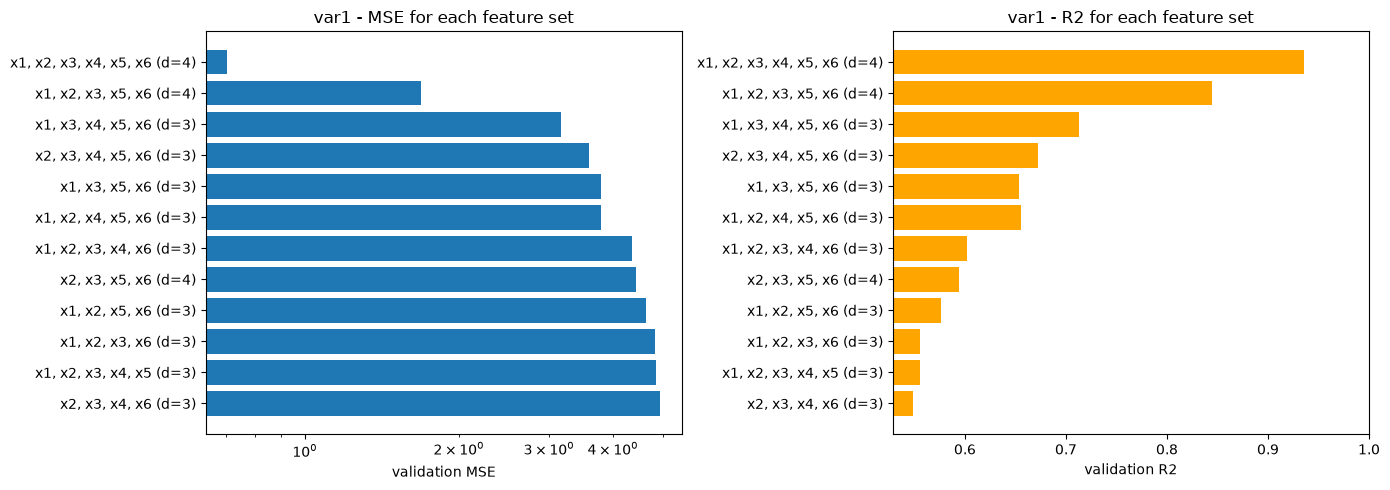

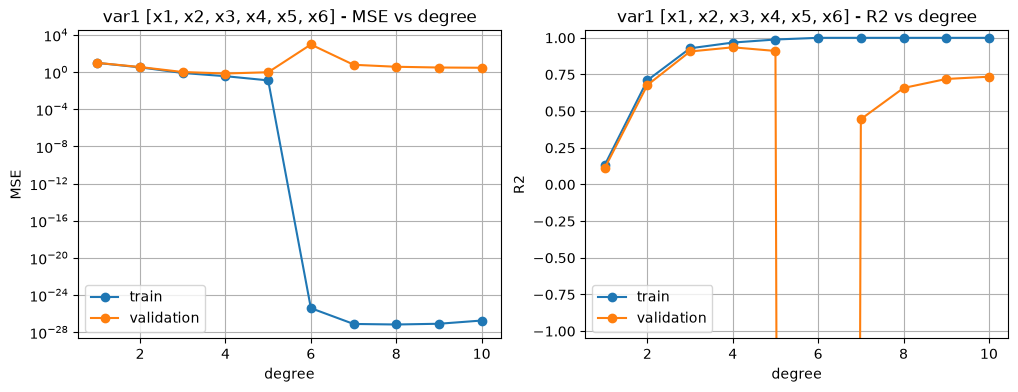

In [7]:
# top 12 feature sets, each at its best degree
top_sets = feature_results.drop_duplicates("features").head(12)
labels = top_sets["features"] + " (d=" + top_sets["degree"].astype(str) + ")"

fig, (mse_plot, r2_plot) = plt.subplots(1, 2, figsize=(14, 5))

mse_plot.barh(labels, top_sets["val_mse"])
mse_plot.set_xscale("log")
mse_plot.invert_yaxis()
mse_plot.set_xlabel("validation MSE")
mse_plot.set_title("var1 - MSE for each feature set")

r2_plot.barh(labels, top_sets["val_r2"], color="orange")
r2_plot.invert_yaxis()
r2_plot.set_xlim(max(top_sets["val_r2"].min(), 0) - 0.02, 1)
r2_plot.set_xlabel("validation R2")
r2_plot.set_title("var1 - R2 for each feature set")

plt.tight_layout()
plt.savefig("Var1_2_features.png", dpi=200, bbox_inches="tight")
plt.show()

# scores vs degree for the best feature set
best_set = feature_results.loc[0, "features"]
best_set_results = feature_results[feature_results["features"] == best_set].sort_values("degree")
plot_degree_sweep(best_set_results, "var1 [" + best_set + "]", "Var1_3_bestset.png")

## Ridge and Lasso regularization
The same polynomial model with an L2 (ridge) or L1 (lasso) penalty on the coefficients. All features are used, and the degree is varied together with the penalty strength alpha.

In [8]:
ridge_alphas = [0.001, 0.01, 0.1, 1, 10]
lasso_alphas = [0.001, 0.01, 0.1]


def reg_sweep(reg, alphas):
    rows = []
    for degree in range(1, max_degree + 1):
        for alpha in alphas:
            tr_mse, v_mse, tr_r2, v_r2 = kfold_scores(features, degree, reg, alpha)
            rows.append([degree, alpha, tr_mse, v_mse, tr_r2, v_r2])
    results = pd.DataFrame(rows, columns=["degree", "alpha", "train_mse", "val_mse", "train_r2", "val_r2"])
    return results.sort_values("val_mse").reset_index(drop=True)


ridge_results = reg_sweep("ridge", ridge_alphas)
lasso_results = reg_sweep("lasso", lasso_alphas)

print("ridge - top 5")
print(ridge_results.head())
print("\nlasso - top 5")
print(lasso_results.head())

ridge - top 5
   degree  alpha  train_mse   val_mse  train_r2    val_r2
0       5   10.0   0.160741  0.451031  0.985681  0.958630
1       6   10.0   0.107999  0.549019  0.990378  0.949302
2       5    1.0   0.133178  0.629635  0.988137  0.942126
3       4   10.0   0.379167  0.653914  0.966222  0.940020
4       4    1.0   0.363270  0.690391  0.967638  0.936706

lasso - top 5
   degree  alpha  train_mse   val_mse  train_r2    val_r2
0       5   0.01   0.228915  0.317351  0.979607  0.970990
1       6   0.01   0.214645  0.321702  0.980878  0.970422
2       7   0.01   0.206405  0.332523  0.981612  0.969519
3       8   0.01   0.200888  0.336646  0.982104  0.969047
4       9   0.01   0.197426  0.343177  0.982412  0.968446


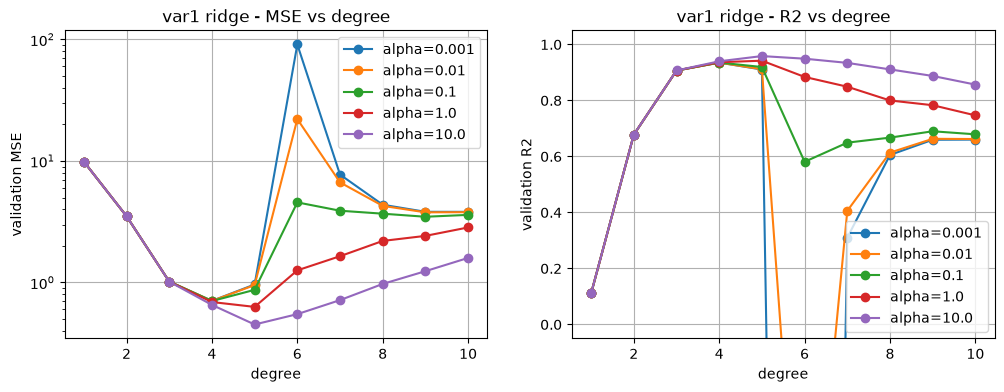

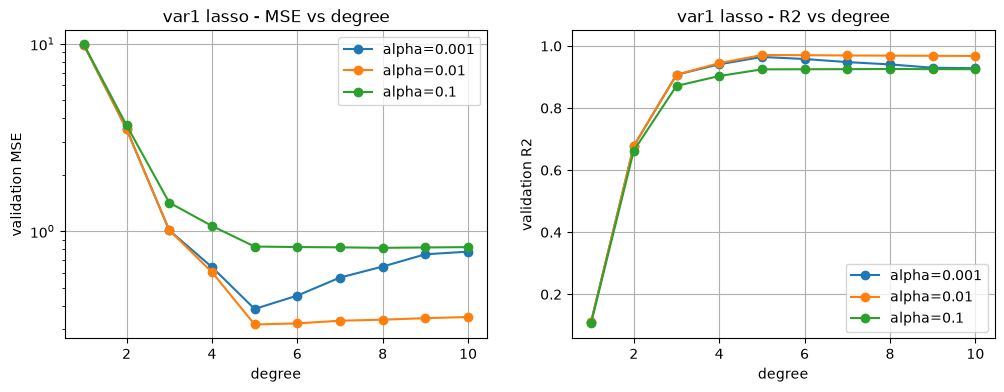

In [9]:
def plot_reg_sweep(results, title, file_name):
    # one curve per alpha
    fig, (mse_plot, r2_plot) = plt.subplots(1, 2, figsize=(12, 4))

    for alpha in sorted(results["alpha"].unique()):
        one_alpha = results[results["alpha"] == alpha].sort_values("degree")
        mse_plot.plot(one_alpha["degree"], one_alpha["val_mse"], marker="o", label="alpha=" + str(alpha))
        r2_plot.plot(one_alpha["degree"], one_alpha["val_r2"], marker="o", label="alpha=" + str(alpha))

    mse_plot.set_yscale("log")
    mse_plot.set_xlabel("degree")
    mse_plot.set_ylabel("validation MSE")
    mse_plot.set_title(title + " - MSE vs degree")
    mse_plot.legend()
    mse_plot.grid(True)

    r2_plot.set_ylim(max(results["val_r2"].min(), 0) - 0.05, 1.05)
    r2_plot.set_xlabel("degree")
    r2_plot.set_ylabel("validation R2")
    r2_plot.set_title(title + " - R2 vs degree")
    r2_plot.legend()
    r2_plot.grid(True)

    plt.savefig(file_name, dpi=200, bbox_inches="tight")
    plt.show()


plot_reg_sweep(ridge_results, "var1 ridge", "Var1_4_ridge.png")
plot_reg_sweep(lasso_results, "var1 lasso", "Var1_5_lasso.png")

## Final model and predictions
The best of plain, ridge and lasso by validation MSE is trained on the full training set and used to predict on the test set.

  method                  features  degree  alpha   val_mse   val_r2
0   none  [x1, x2, x3, x4, x5, x6]       4   0.00  0.705487  0.93535
1  ridge  [x1, x2, x3, x4, x5, x6]       5  10.00  0.451031  0.95863
2  lasso  [x1, x2, x3, x4, x5, x6]       5   0.01  0.317351  0.97099


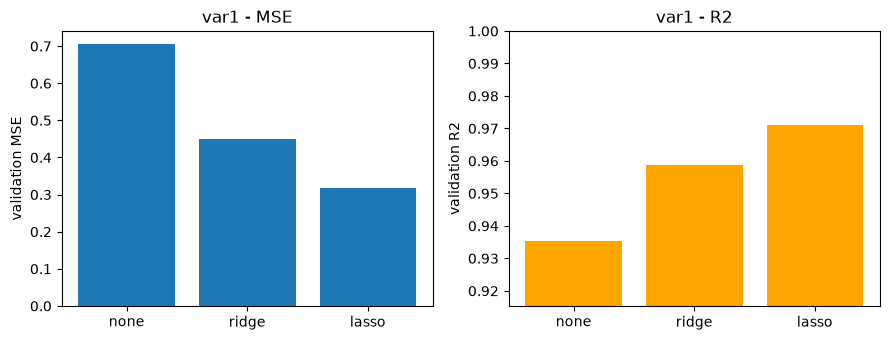

using: lasso | features ['x1', 'x2', 'x3', 'x4', 'x5', 'x6'] | degree 5 | alpha 0.01
1000 predictions saved to BT2024028_pred_var1.csv


In [10]:
# best result of each method
best_plain = feature_results.loc[0]
best_ridge = ridge_results.loc[0]
best_lasso = lasso_results.loc[0]

comparison = pd.DataFrame([
    ["none", best_plain["features"].split(", "), int(best_plain["degree"]), 0, best_plain["val_mse"], best_plain["val_r2"]],
    ["ridge", features, int(best_ridge["degree"]), best_ridge["alpha"], best_ridge["val_mse"], best_ridge["val_r2"]],
    ["lasso", features, int(best_lasso["degree"]), best_lasso["alpha"], best_lasso["val_mse"], best_lasso["val_r2"]],
], columns=["method", "features", "degree", "alpha", "val_mse", "val_r2"])
print(comparison)

fig, (mse_plot, r2_plot) = plt.subplots(1, 2, figsize=(9, 3.5))
mse_plot.bar(comparison["method"], comparison["val_mse"])
mse_plot.set_ylabel("validation MSE")
mse_plot.set_title("var1 - MSE")
r2_plot.bar(comparison["method"], comparison["val_r2"], color="orange")
r2_plot.set_ylim(comparison["val_r2"].min() - 0.02, 1)
r2_plot.set_ylabel("validation R2")
r2_plot.set_title("var1 - R2")
plt.tight_layout()
plt.savefig("Var1_6_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

best = comparison.sort_values("val_mse").iloc[0]
print("using:", best["method"], "| features", best["features"], "| degree", best["degree"], "| alpha", best["alpha"])

# fit on the full training data and predict on test
final_model = build_model(best["degree"], best["method"], best["alpha"])
final_model.fit(train[best["features"]].values, train["y"].values)
predictions = final_model.predict(test[best["features"]].values)

pd.DataFrame({"y": predictions}).to_csv("BT2024028_pred_var1.csv", index=False)
print(len(predictions), "predictions saved to BT2024028_pred_var1.csv")